In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [11]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [10]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import *
pfns = PlottingFns()

In [3]:
dot_ds = DOT().ds

In [14]:
sla_da = SLA(deg=0.25).da
lwe_ds = GRACE().ds

In [ ]:
ds_raw = SLA(deg=1).ds_initial

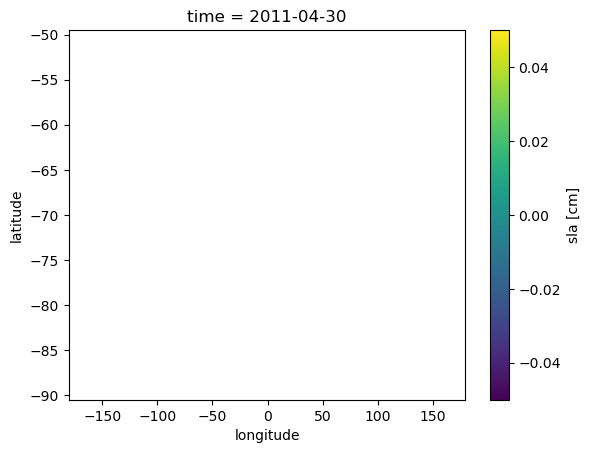

In [12]:
ds_raw.isel(time=99).sla.plot()

In [30]:
sha_ds_dot = StericHeight(
    ssh_ref = "DOT",
    ssh = dot_ds.dot,
    lwe = lwe_ds.lwe_thickness
).get_sha()

In [31]:
sha_ds = StericHeight(
    ssh_ref = "DOT",
    ssh = sla_ds.sla,
    lwe = lwe_ds.lwe_thickness
).get_sha()

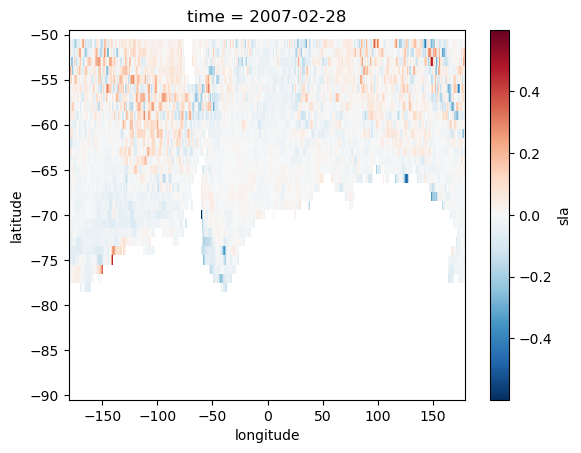

In [32]:
sla_ds.sla.isel(time=49).plot()

In [33]:
dot_ds

<xarray.Dataset> Size: 217MB
Dimensions:          (time: 196, latitude: 64, longitude: 360, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-07-01 ... 2018-10-01
  * edge_lat         (edge_lat) float64 520B -82.0 -81.5 -81.0 ... -50.5 -50.0
  * edge_lon         (edge_lon) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    dot              (time, latitude, longitude) float64 36MB nan nan ... -67.4
    ug               (longitude, latitude, time) float64 36MB ...
    vg               (longitude, latitude, time) float64 36MB ...
    land_mask        (longitude, latitude) float64 184kB ...
    intersat_offset  float64 8B ...
    mdt              (latitude, longitude) float64 184kB nan nan ... -72.67
    dota             (time, latitude, longitude) float64 36MB nan nan ... 5.278
    dot_trend        (time, latitude, longitude) float64 36MB nan nan ... -69.09
    dota_trend       (time, latitude, longitude) float64 36MB nan nan ... 3.589
Attributes:
    history:      Created 08/01/2022, 00:5223
    description:  ENVISAT + CryoSat2 altimetry (geoid:_goco05c) \nenv: 07.200...

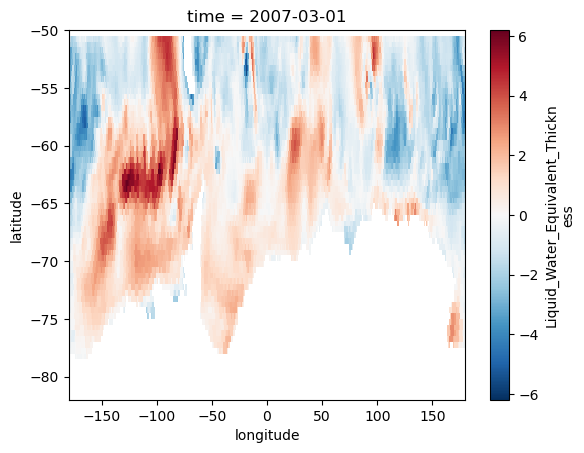

In [34]:
sha_ds_dot.lwe.isel(time=56).plot()

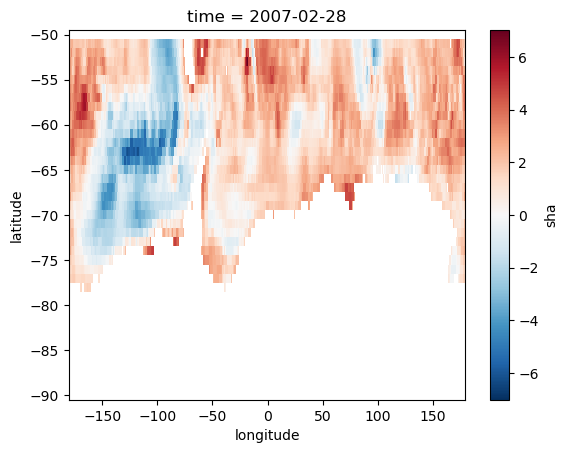

In [35]:
sha_ds.sha.isel(time=49).plot()

In [6]:
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/site-packages/xarray/core/nputils.py:248: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


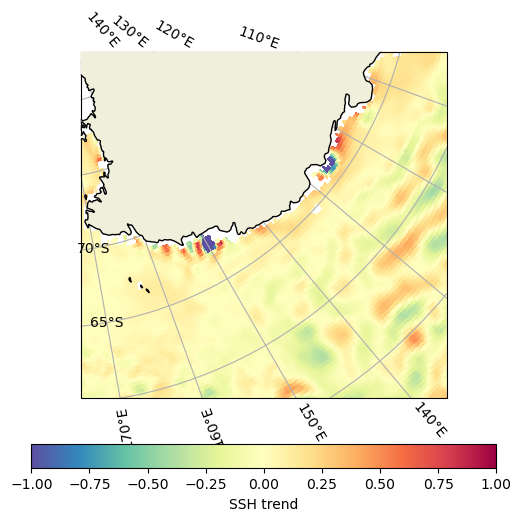

In [16]:
fig, ax = plt.subplots(figsize=(6,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,get_trend(sla_da),vmax=1,cbar='SSH trend',extent=[115,170,-75,-60])